# LECTURE 7
**Topic:** Matrix-Vector Product; Matrix of a Linear Transformation; Matrix-Matrix Product  
**Textbook References:** Sections 2.1, 2.2.1, 2.2.2

---

## Key Points

- $Ax$ (m×n matrix, n-vector) is computed as the dot product of each row of $A$ with $x$. Result is m-vector.
- For fixed $A$: $A(c_1 x^{(1)}+c_2 x^{(2)}) = c_1 Ax^{(1)}+c_2 Ax^{(2)}$ (**linearity/superposition**).
- Every linear transformation $\mathbb{R}^n\to\mathbb{R}^m$ has an $m\times n$ matrix. Column $j$ = image of $j$-th unit vector.
- $(AB)_{ij}$ = dot product of $i$-th row of $A$ and $j$-th column of $B$.


---
## Theory and Examples

### 1-3. Matrices, Vectors, and Basic Operations

An $m\times n$ matrix $A$ has entries $a_{ij}$ (row $i$, column $j$). Space of real $m\times n$ matrices: $\mathbb{R}^{m\times n}$.

**Sum:** $(A+B)_{ij} = a_{ij}+b_{ij}$ &emsp; **Scaling:** $(cA)_{ij} = ca_{ij}$

### 4. The Matrix-Vector Product

For $A$ ($m\times n$) and $x$ ($n\times 1$):
$$y_i = \sum_{j=1}^n a_{ij} x_j \quad \forall i$$

Equivalently: $y = Ax$ is a **linear combination of the columns of $A$** with coefficients from $x$.

### 5. Example

$$\begin{bmatrix}3&1&-1\\2&-1&5\end{bmatrix}\begin{bmatrix}2\\-1\\-4\end{bmatrix} = \begin{bmatrix}9\\-15\end{bmatrix}$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Example 5: matrix-vector product
A = np.array([[3,1,-1],[2,-1,5]])
x = np.array([2,-1,-4])
y = A @ x

print('=== Matrix-Vector Product ===')
print(f'A =\n{A}')
print(f'x = {x}')
print(f'y = Ax = {y}')
print()
# Show as dot products
for i in range(A.shape[0]):
    print(f'  Row {i}: {A[i]} . {x} = {A[i]@x}')

# Example 7: linearity
print('\n=== Superposition Property ===')
# Au = [-1, 4], Av = [5, -2]
# A(u-2v) = Au - 2Av = [-1,4] - 2*[5,-2] = [-11, 8]
Au = np.array([-1, 4])
Av = np.array([5, -2])
result = Au - 2*Av
print(f'Au = {Au}, Av = {Av}')
print(f'A(u-2v) = Au - 2Av = {Au} - 2*{Av} = {result}')

=== Matrix-Vector Product ===
A =
[[ 3  1 -1]
 [ 2 -1  5]]
x = [ 2 -1 -4]
y = Ax = [  9 -15]

  Row 0: [ 3  1 -1] . [ 2 -1 -4] = 9
  Row 1: [ 2 -1  5] . [ 2 -1 -4] = -15

=== Superposition Property ===
Au = [-1  4], Av = [ 5 -2]
A(u-2v) = Au - 2Av = [-1  4] - 2*[ 5 -2] = [-11   8]


---
### 6. Linearity and the Superposition Property

For any matrix $A$:
$$A(c_1 x^{(1)} + c_2 x^{(2)}) = c_1 A x^{(1)} + c_2 A x^{(2)}$$

This is the **superposition property** and makes $A$ a **linear transformation** from $\mathbb{R}^n$ to $\mathbb{R}^m$.

### 7. Example: Superposition

If $Au = [-1,\,4]^T$ and $Av = [5,\,-2]^T$, then:
$$A(u-2v) = Au - 2Av = [-1,4]^T - 2[5,-2]^T = [-11,8]^T$$

### 8–10. Matrix of a Linear Transformation

**Every** linear transformation $T:\mathbb{R}^n\to\mathbb{R}^m$ has a matrix $A$ such that $T(x)=Ax$.  
To find $A$: apply $T$ to each standard unit vector $e^{(j)}$. The result $T(e^{(j)})$ is the $j$-th **column** of $A$.

### 11. Example: Linear Transformation from Unit Vector Images

If $T(e^{(1)})=[3,-1,0]^T$, $T(e^{(2)})=[-1,5,4]^T$, $T(e^{(3)})=[1,-1,1]^T$, then:
$$A = \begin{bmatrix}3&-1&1\\-1&5&-1\\0&4&1\end{bmatrix}$$


In [2]:
# Linear transformation matrix from unit vector images
A_from_cols = np.array([[3,-1,1],[-1,5,-1],[0,4,1]])
print('Matrix A (columns = images of unit vectors):')
print(A_from_cols)
# Verify: A @ e1 should give first column
e1 = np.array([1,0,0]); e2 = np.array([0,1,0]); e3 = np.array([0,0,1])
print(f'A @ e1 = {A_from_cols @ e1} (should be [3,-1,0])')
print(f'A @ e2 = {A_from_cols @ e2} (should be [-1,5,4])')
print(f'A @ e3 = {A_from_cols @ e3} (should be [1,-1,1])')

# Example 12: Projection onto horizontal axis
print('\n=== Projection onto Horizontal Axis ===')
A_proj = np.array([[1,0],[0,0]])
print(f'A_proj = {A_proj}')
test_vecs = [[1,0],[0,1],[3,4],[-2,5]]
for v in test_vecs:
    v = np.array(v)
    print(f'  Project {v} -> {A_proj @ v}')

# Example 13: Rotation by 30 degrees
theta_rot = np.pi/6  # 30 degrees
B_rot = np.array([[np.cos(theta_rot), -np.sin(theta_rot)],
                  [np.sin(theta_rot),  np.cos(theta_rot)]])
print(f'\n=== Rotation by 30 degrees ===')
print(f'B = {B_rot.round(4)}')
for v in [[1,0],[0,1],[1,1]]:
    v = np.array(v)
    rotated = B_rot @ v
    print(f'  Rotate {v} -> {rotated.round(4)}')

Matrix A (columns = images of unit vectors):
[[ 3 -1  1]
 [-1  5 -1]
 [ 0  4  1]]
A @ e1 = [ 3 -1  0] (should be [3,-1,0])
A @ e2 = [-1  5  4] (should be [-1,5,4])
A @ e3 = [ 1 -1  1] (should be [1,-1,1])

=== Projection onto Horizontal Axis ===
A_proj = [[1 0]
 [0 0]]
  Project [1 0] -> [1 0]
  Project [0 1] -> [0 0]
  Project [3 4] -> [3 0]
  Project [-2  5] -> [-2  0]

=== Rotation by 30 degrees ===
B = [[ 0.866 -0.5  ]
 [ 0.5    0.866]]
  Rotate [1 0] -> [0.866 0.5  ]
  Rotate [0 1] -> [-0.5    0.866]
  Rotate [1 1] -> [0.366 1.366]


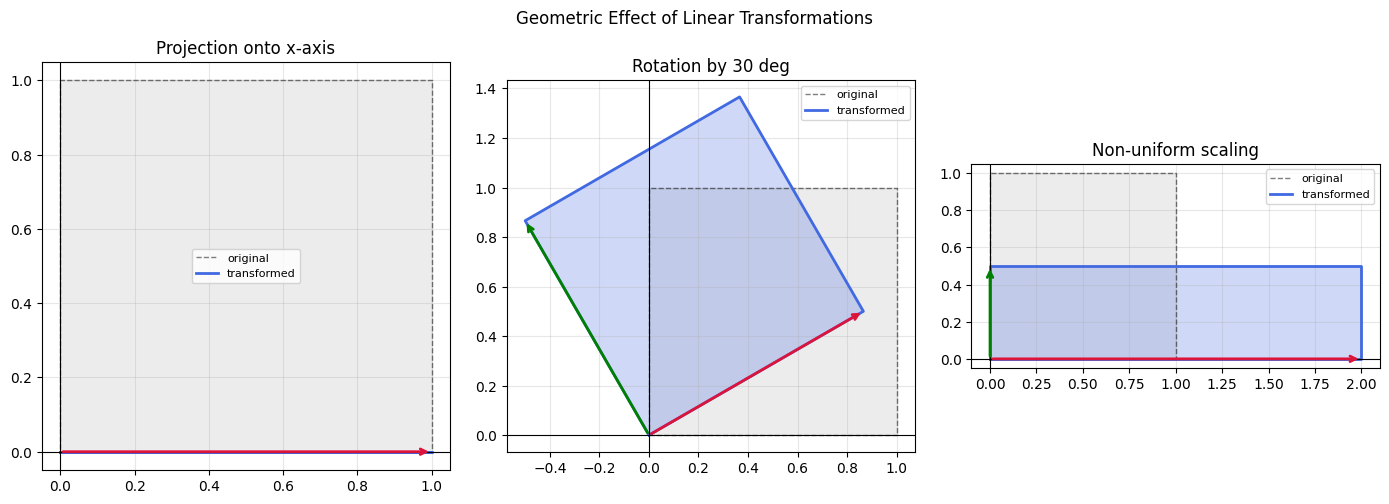

In [7]:
# Visualize linear transformations
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

def plot_transform(ax, mat, title, colors=['royalblue','crimson','green','orange']):
    # Draw a square grid and its transformation
    pts = np.array([[0,0],[1,0],[1,1],[0,1],[0,0]]).T
    xf  = mat @ pts
    ax.plot(pts[0], pts[1], 'k--', lw=1, alpha=0.5, label='original')
    ax.fill(pts[0,:-1], pts[1,:-1], alpha=0.15, color='gray')
    ax.plot(xf[0], xf[1], color='royalblue', lw=2, label='transformed')
    ax.fill(xf[0,:-1], xf[1,:-1], alpha=0.25, color='royalblue')
    # Unit vectors
    for e, col in [([1,0],'crimson'), ([0,1],'green')]:
        e = np.array(e)
        te = mat @ e
        ax.annotate('',xy=(te[0],te[1]),xytext=(0,0),
                    arrowprops=dict(arrowstyle='->', color=col,lw=2))
    ax.axhline(0, color='k',lw=0.8); ax.axvline(0, color='k',lw=0.8)
    ax.grid(True,alpha=0.3); ax.set_aspect('equal')
    ax.set_title(title); ax.legend(fontsize=8)

plot_transform(axes[0], np.array([[1,0],[0,0]]), 'Projection onto x-axis')
B_rot = np.array([[np.cos(np.pi/6),-np.sin(np.pi/6)],[np.sin(np.pi/6),np.cos(np.pi/6)]])
plot_transform(axes[1], B_rot, 'Rotation by 30 deg')
A_scale = np.array([[2,0],[0,0.5]])
plot_transform(axes[2], A_scale, 'Non-uniform scaling')

plt.suptitle('Geometric Effect of Linear Transformations', fontsize=12)
plt.tight_layout(); plt.show()

---
### 9. Image Scaling Task

A 36-inch diagonal display (16:9 aspect ratio). Display on a 27-inch display (4:3 ratio).  
Find the scaling matrix $aI$ that makes the image as large as possible without distortion or cropping.

**Solution:**
- 36" diagonal, 16:9: $w_{36}=36\cos(\theta)$, $h_{36}=36\sin(\theta)$ where $\tan\theta=9/16$.
- 27" diagonal, 4:3: $w_{27}=27\cos(\phi)$, $h_{27}=27\sin(\phi)$ where $\tan\phi=3/4$.
- Scaling $a$ must fit both dimensions: $a = \min(w_{27}/w_{36},\; h_{27}/h_{36})$.


In [8]:
# Image scaling task
import numpy as np

# 36-inch, 16:9
d36 = 36.0
ar36 = (16, 9)
diag36 = np.sqrt(ar36[0]**2 + ar36[1]**2)
w36 = d36 * ar36[0] / diag36
h36 = d36 * ar36[1] / diag36

# 27-inch, 4:3
d27 = 27.0
ar27 = (4, 3)
diag27 = np.sqrt(ar27[0]**2 + ar27[1]**2)
w27 = d27 * ar27[0] / diag27
h27 = d27 * ar27[1] / diag27

# Scaling factor
a = min(w27/w36, h27/h36)

print(f'36-inch 16:9:  w={w36:.3f}", h={h36:.3f}"')
print(f'27-inch 4:3:   w={w27:.3f}", h={h27:.3f}"')
print(f'Scale by w: {w27/w36:.4f}')
print(f'Scale by h: {h27/h36:.4f}')
print(f'a = min = {a:.4f}')
print(f'Scaling matrix aI = {a:.4f} * I')
print(f'Scaled image size: {a*w36:.3f}" x {a*h36:.3f}" (fits within {w27:.3f}" x {h27:.3f}")')

36-inch 16:9:  w=31.377", h=17.649"
27-inch 4:3:   w=21.600", h=16.200"
Scale by w: 0.6884
Scale by h: 0.9179
a = min = 0.6884
Scaling matrix aI = 0.6884 * I
Scaled image size: 21.600" x 12.150" (fits within 21.600" x 16.200")


---
### 14-15. Matrix-Matrix Product

If $A$ is $m\times p$ and $B$ is $p\times n$, then $AB$ is $m\times n$ with:
$$(AB)_{ij} = \sum_{k=1}^p a_{ik} b_{kj}$$

(dot product of $i$-th row of $A$ with $j$-th column of $B$)

**Inner dimension** must match: columns of $A$ = rows of $B = p$.

**Example:**
$$\begin{bmatrix}2&-1&4\\1&0&-1\end{bmatrix}\begin{bmatrix}1&-2\\0&3\\1&5\end{bmatrix} = \begin{bmatrix}6&13\\0&-7\end{bmatrix}$$


In [9]:
A = np.array([[2,-1,4],[1,0,-1]])
B = np.array([[1,-2],[0,3],[1,5]])
AB = A @ B
print(f'A ({A.shape}):\n{A}')
print(f'B ({B.shape}):\n{B}')
print(f'AB ({AB.shape}):\n{AB}')
print()
# Verify element by element
print('Element-by-element verification:')
for i in range(A.shape[0]):
    for j in range(B.shape[1]):
        val = np.dot(A[i,:], B[:,j])
        print(f'  AB[{i},{j}] = row{i} of A . col{j} of B = {A[i,:]} . {B[:,j]} = {val}')

A ((2, 3)):
[[ 2 -1  4]
 [ 1  0 -1]]
B ((3, 2)):
[[ 1 -2]
 [ 0  3]
 [ 1  5]]
AB ((2, 2)):
[[ 6 13]
 [ 0 -7]]

Element-by-element verification:
  AB[0,0] = row0 of A . col0 of B = [ 2 -1  4] . [1 0 1] = 6
  AB[0,1] = row0 of A . col1 of B = [ 2 -1  4] . [-2  3  5] = 13
  AB[1,0] = row1 of A . col0 of B = [ 1  0 -1] . [1 0 1] = 0
  AB[1,1] = row1 of A . col1 of B = [ 1  0 -1] . [-2  3  5] = -7


---
## Summary

| Operation | Formula | Condition |
|---|---|---|
| Matrix-vector product | $y = Ax$ | $A$: $m\times n$, $x$: $n\times 1$ |
| Linearity | $A(c_1x^{(1)}+c_2x^{(2)}) = c_1Ax^{(1)}+c_2Ax^{(2)}$ | always |
| Matrix of $T$ | columns = $T(e^{(j)})$ | $T$ linear |
| Matrix product | $(AB)_{ij} = $ row$_i(A)\cdot$col$_j(B)$ | inner dims match |

### Mistakes to Avoid
1. Getting $Ax$ wrong: it's each **row** of $A$ dotted with $x$, NOT each column.
2. Inner dimension mismatch in $AB$: columns of $A$ must equal rows of $B$.
3. Assuming $AB = BA$ — matrix multiplication is generally **not commutative**.
